# Funciones de distribución de probabilidades

## Distribución Uniforme

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
a = 1
b = 100
n = 1000000
data = np.random.uniform(a, b, n)

(array([100169., 100061., 100474.,  99994.,  99697.,  99991., 100013.,
         99844., 100047.,  99710.]),
 array([ 1.00005072, 10.90004049, 20.80003026, 30.70002003, 40.60000979,
        50.49999956, 60.39998933, 70.2999791 , 80.19996887, 90.09995863,
        99.9999484 ]),
 <BarContainer object of 10 artists>)

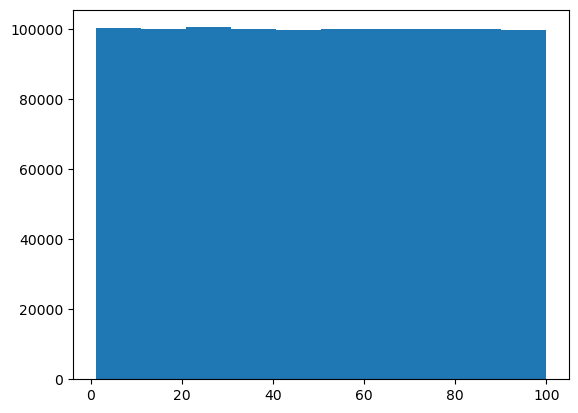

In [6]:
%matplotlib inline
plt.hist(data)

## Distribución Normal

In [8]:
data = np.random.randn(1000000)

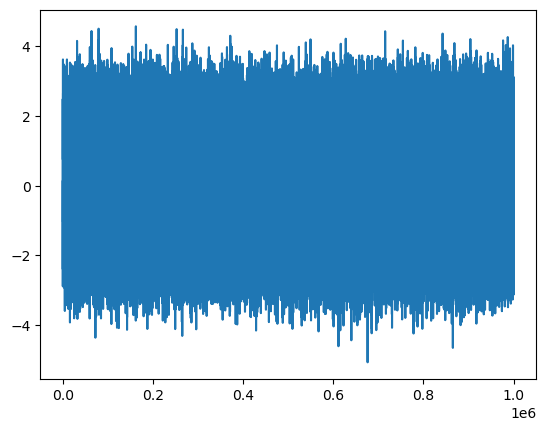

In [9]:
x = range(1,1000001)
plt.plot(x, data)

(array([1.90000e+01, 8.47000e+02, 1.40580e+04, 9.79490e+04, 2.89285e+05,
        3.60483e+05, 1.90534e+05, 4.27230e+04, 3.94900e+03, 1.53000e+02]),
 array([-5.05769493, -4.09582709, -3.13395925, -2.17209141, -1.21022357,
        -0.24835573,  0.71351211,  1.67537995,  2.63724779,  3.59911563,
         4.56098347]),
 <BarContainer object of 10 artists>)

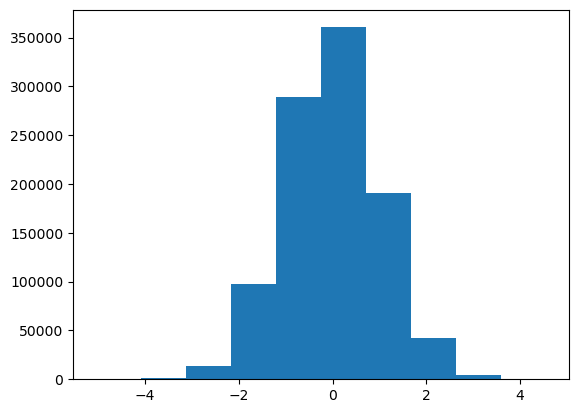

In [10]:
%matplotlib inline
plt.hist(data)

### Función de distribución acumulada

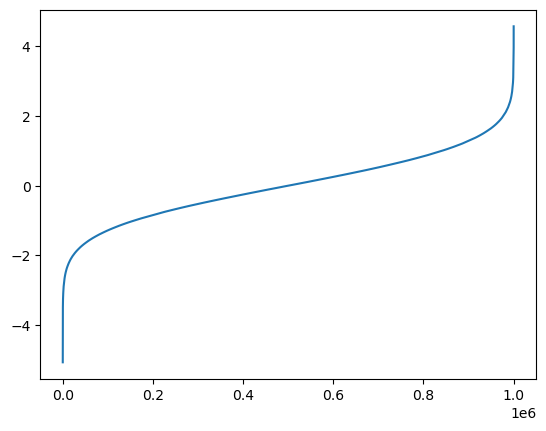

In [12]:
plt.plot(x,sorted(data))

(array([  19.,  130.,  633., 1704., 2704., 2561., 1543.,  574.,  115.,
          17.]),
 array([-3.45715089, -1.64144098,  0.17426894,  1.98997885,  3.80568877,
         5.62139868,  7.4371086 ,  9.25281852, 11.06852843, 12.88423835,
        14.69994826]),
 <BarContainer object of 10 artists>)

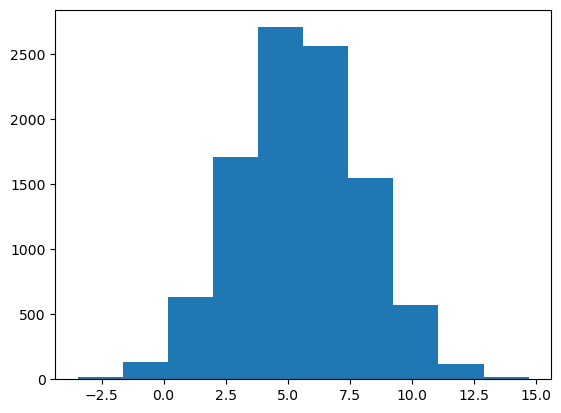

In [13]:
mu = 5.5
sd = 2.5
Z_10000 = np.random.randn(10000)
data = mu + sd * Z_10000 # Z = (X -mu) / sd -> N(0,1), X = mu + sd * Z
plt.hist(data)

### Mas de un array

In [15]:
data = np.random.randn(2,4)
data

array([[-0.69630535,  0.41714719, -1.86867976, -0.65033196],
       [ 1.0291257 ,  0.29989621, -0.83696364, -1.49655156]])

## La Simulación de Monte Carlo

* Generamos 2 números aleatorios uniformes x e y entre 0 y 1
* Calcularemos x * x + y * y
    * Si el valor es inferior a 1 -> estamos dentro del círculo
    * Si el valor es superior a 1 -> estamos fuera del círculo
* Calculamos el número total de veces que estan dentro del círculo y lo dividimos entre el número total de intentos para obtener una aproximación de la probabilidad de caer dentro del círculo.
* Usamos dicha probabilidad para aproximar el valor de pi
* Repetimos el experimento un número suficiente de veces (por ejemplo 100), para obtener diferentes aproximaciones de pi 
* Calculamos el promedio de los 100 expermientos anteriores para dar un valor final de pi.

In [18]:
def pi_montecarlo(n, n_exp):
    pi_avg = 0
    pi_value_list = []
    for i in range(n_exp):
        value = 0
        x = np.random.uniform(0,1,n).tolist()
        y = np.random.uniform(0,1,n).tolist()
        for j in range(n):
            z = np.sqrt(x[j] * x[j] + y[j] * y[j])
            if z <=1 :
                value +=1
        float_value = float(value)
        pi_value = float_value * 4 / n
        pi_value_list.append(pi_value)
        pi_avg += pi_value
    
    pi = pi_avg/n_exp
    print(pi)
    fig = plt.plot(pi_value_list)
    return pi, fig

3.142708000000001


(3.142708000000001, [<matplotlib.lines.Line2D at 0x77f9b5d77bc0>])

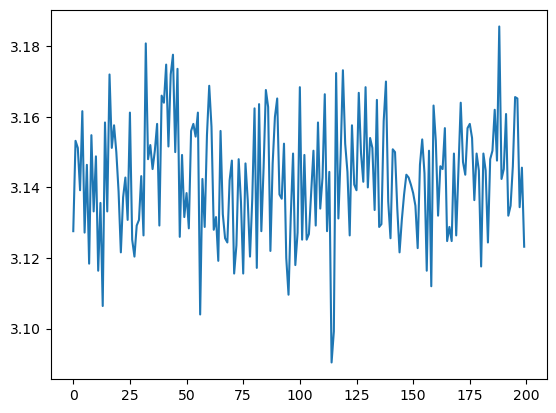

In [19]:
pi_montecarlo(10000,200)

## Dummy Data Sets

In [21]:
n = 1000000
data = pd.DataFrame(
    {
        "A": np.random.randn(n),
        "B": 1.5 + 2.5 * np.random.randn(n),
        "C": np.random.uniform(5,32,n)
    }
)

In [22]:
data.head()

,A,B,C
0,0.459028,0.238048,9.410614
1,0.117897,-2.438016,28.718252
2,1.635967,-1.056189,13.633466
3,-1.271749,2.794114,25.929732
4,0.121965,-3.111156,28.558204


In [23]:
data.describe()

,A,B,C
count,1000000.000000,1000000.000000,1000000.000000
mean,0.000308,1.501197,18.499339
std,0.999729,2.500411,7.790402
min,-4.570002,-10.973208,5.000066
25%,-0.673661,-0.188219,11.753802
50%,0.000693,1.499398,18.505993
75%,0.673557,3.184416,25.238548
max,4.893207,13.173569,31.999979


(array([1.51000e+02, 3.52700e+03, 3.79050e+04, 1.74610e+05, 3.48036e+05,
        3.02153e+05, 1.13564e+05, 1.87060e+04, 1.30600e+03, 4.20000e+01]),
 array([-4.57000241, -3.62368142, -2.67736044, -1.73103945, -0.78471847,
         0.16160252,  1.1079235 ,  2.05424449,  3.00056547,  3.94688646,
         4.89320744]),
 <BarContainer object of 10 artists>)

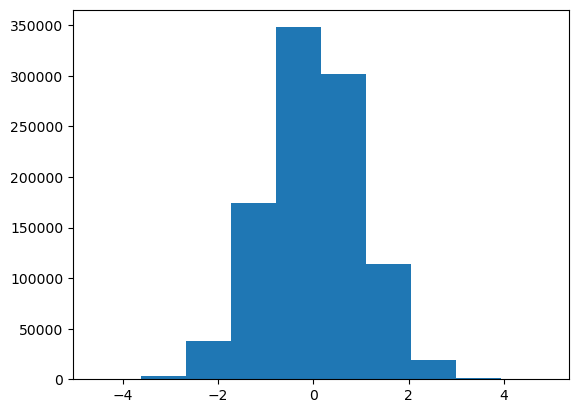

In [24]:
plt.hist(data["A"])

(array([1.60000e+01, 1.10300e+03, 1.69680e+04, 1.11830e+05, 3.06860e+05,
        3.53162e+05, 1.71705e+05, 3.52850e+04, 2.97200e+03, 9.90000e+01]),
 array([-10.97320804,  -8.55853037,  -6.14385269,  -3.72917501,
         -1.31449733,   1.10018035,   3.51485802,   5.9295357 ,
          8.34421338,  10.75889106,  13.17356874]),
 <BarContainer object of 10 artists>)

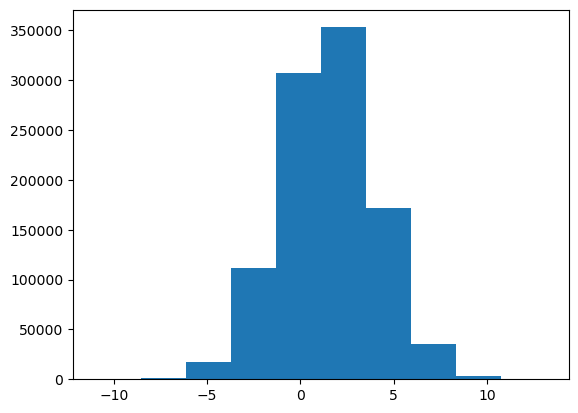

In [25]:
plt.hist(data["B"])

(array([ 99768., 100085., 100095.,  99885.,  99963., 100211., 100364.,
        100191.,  99394., 100044.]),
 array([ 5.00006578,  7.70005712, 10.40004847, 13.10003981, 15.80003116,
        18.50002251, 21.20001385, 23.9000052 , 26.59999654, 29.29998789,
        31.99997924]),
 <BarContainer object of 10 artists>)

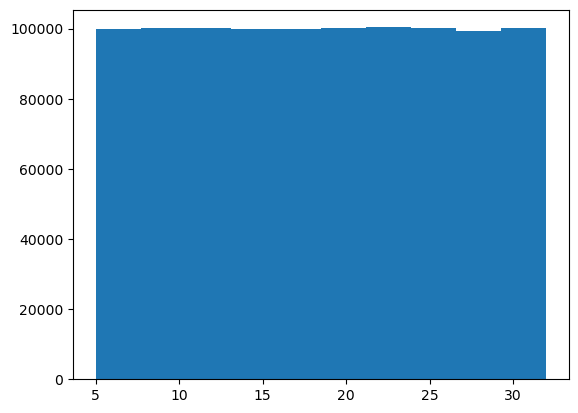

In [26]:
plt.hist(data["C"])

In [27]:
data = pd.read_csv("../datasets/customer-churn-model/Customer Churn Model.txt")

In [28]:
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [29]:
column_names = data.columns.values.tolist()

In [30]:
a = len(column_names)
a

21

In [31]:
new_data = pd.DataFrame(
    {
        "Column Name": column_names,
        "A": np.random.randn(a),
        "B": np.random.uniform(0,1,a)
    }, index=range(42, 42+a)
)

In [32]:
new_data

,Column Name,A,B
42,State,0.603561,0.099043
43,Account Length,-0.503102,0.354122
44,Area Code,-0.061424,0.817331
45,Phone,0.824713,0.511536
46,Int'l Plan,0.725856,0.373543
47,VMail Plan,-1.845673,0.213107
48,VMail Message,-0.068861,0.862148
49,Day Mins,-1.252040,0.912302
50,Day Calls,-1.708714,0.524070
51,Day Charge,-0.516856,0.840404
